# Assignment 2

## RAVDESS label analysis 

Label analysis code (for sanity check) is copied from week 2's notebook example since it is already functional.

In [361]:
#importing the required libraries

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import librosa.display
import soundfile
import os

from glob import glob

import librosa
import IPython.display as ipd

In [362]:
#Emotions in the RAVDESS dataset
emotions_dict ={
  '01':'neutral',
  '02':'calm',
  '03':'happy',
  '04':'sad',
  '05':'angry',
  '06':'fearful',
  '07':'disgust',
  '08':'surprised'
}

In [ ]:
import os, glob

def load_data_without_my_voice(file_path: str):
    X,y=[],[]
    count = 0
    for file in glob.glob(file_path):
        # Skip over directory "Actor_25" because I am the extra actor
        if "./audio/Actor_25" in file:
            continue
        file_name=os.path.basename(file)
        emotion=emotions_dict[file_name.split("-")[2]]
        #features = get_features(file)
        #X.append(features)
        y.append(emotion)
        count += 1
        # '\r' + end='' results in printing over same line
        print('\r' + f' Processed {count}/{1440} audio samples',end=' ')
    # Return arrays to plug into sklearn's cross-validation algorithms
    print(y)
    return np.array(X), np.array(y)

In [364]:
features, emotions = load_data_without_my_voice("./audio/Actor_*/*.wav")

 Processed 1440/1440 audio samples ['happy', 'surprised', 'sad', 'happy', 'disgust', 'fearful', 'neutral', 'disgust', 'happy', 'surprised', 'disgust', 'surprised', 'calm', 'angry', 'surprised', 'sad', 'fearful', 'angry', 'fearful', 'neutral', 'neutral', 'sad', 'happy', 'sad', 'calm', 'happy', 'happy', 'surprised', 'calm', 'sad', 'surprised', 'sad', 'fearful', 'disgust', 'happy', 'calm', 'disgust', 'disgust', 'surprised', 'angry', 'fearful', 'angry', 'angry', 'angry', 'calm', 'calm', 'sad', 'fearful', 'surprised', 'fearful', 'disgust', 'angry', 'fearful', 'neutral', 'calm', 'calm', 'happy', 'angry', 'disgust', 'sad', 'fearful', 'calm', 'surprised', 'angry', 'calm', 'angry', 'sad', 'fearful', 'neutral', 'disgust', 'sad', 'sad', 'happy', 'happy', 'surprised', 'fearful', 'sad', 'fearful', 'angry', 'angry', 'surprised', 'angry', 'disgust', 'calm', 'disgust', 'calm', 'disgust', 'fearful', 'surprised', 'happy', 'surprised', 'sad', 'happy', 'angry', 'surprised', 'sad', 'calm', 'angry', 'happy'

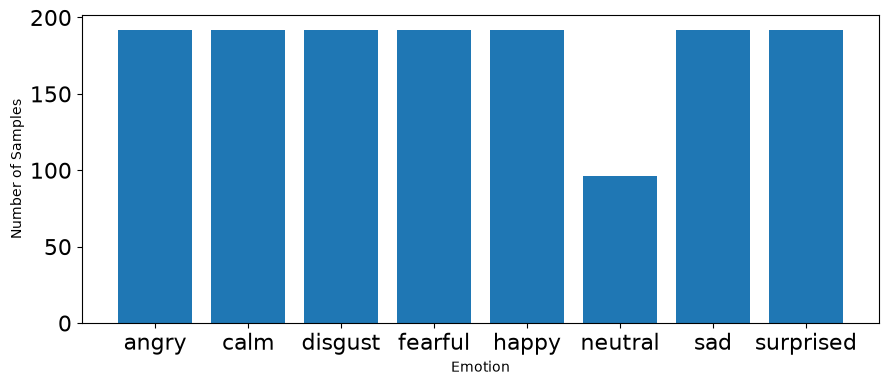

In [365]:
# plot emotions
plt.figure(figsize=(35,4))
plt.subplot(1,3,1)
#np.unique returns ordered list of unique elements and count of each element
emotion_list, count = np.unique(emotions, return_counts=True)
plt.bar(x=range(8), height=count)
plt.xticks(ticks=range(8), labels = [emotion for emotion in emotion_list],fontsize=10)
plt.xlabel('Emotion')
plt.tick_params(labelsize=16)
plt.ylabel('Number of Samples')
plt.show()

## Personal voice label analysis

My own voice is recorded inside `./audio/custom`. There are a total of 8 audio files. 
- Modality: always `03`, because there is only 1 sentence to be said
- Vocal channel: always `01`, it is a speech
- Emotion: all 8 emotions are covered
- Emotional Intensity: always `01`, only normal
- Statement: always `01`, matches with the given statement: `Kids are talking by the door`
- Repetition: only once per emotion, so `01`
- Actor: `25`, I am the extra actor

In [ ]:
my_features, my_emotions = load_data_without_my_voice("./audio/custom/*.wav")
# Actor_25 directory is a copy of custom directory. This is a little confusing but it works by just changing the directory path to only custom

 Processed 8/1440 audio samples ['sad', 'calm', 'disgust', 'neutral', 'angry', 'happy', 'fearful', 'surprised']


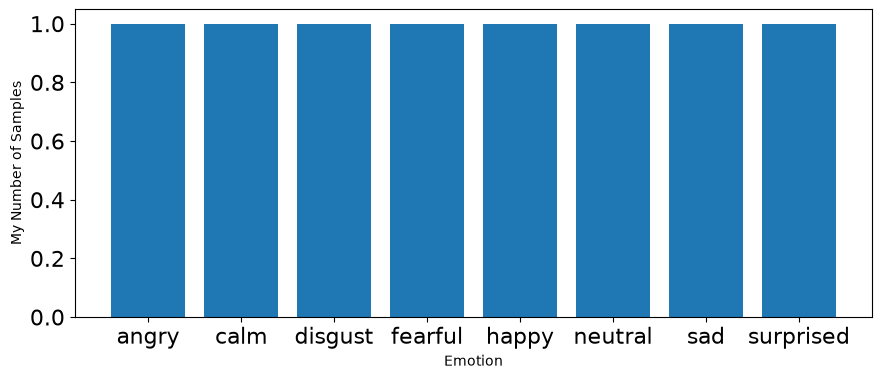

In [367]:
# plot emotions
plt.figure(figsize=(35,4))
plt.subplot(1,3,1)
#np.unique returns ordered list of unique elements and count of each element
emotion_list, count = np.unique(my_emotions, return_counts=True)
plt.bar(x=range(8), height=count)
plt.xticks(ticks=range(8), labels = [emotion for emotion in emotion_list],fontsize=10)
plt.xlabel('Emotion')
plt.tick_params(labelsize=16)
plt.ylabel('My Number of Samples')
plt.show()

## Combined label analysis

In [368]:
import os, glob

def load_data_combined(file_path: str):
    X,y=[],[]
    count = 0
    for file in glob.glob(file_path):
        file_name=os.path.basename(file)
        emotion=emotions_dict[file_name.split("-")[2]]
        #features = get_features(file)
        #X.append(features)
        y.append(emotion)
        count += 1
        # '\r' + end='' results in printing over same line
        print('\r' + f' Processed {count}/{1440} audio samples',end=' ')
    # Return arrays to plug into sklearn's cross-validation algorithms
    return np.array(X), np.array(y)

In [369]:
features_combined, emotions_combined = load_data_combined("./audio/Actor_*/*.wav")

 Processed 1448/1440 audio samples 

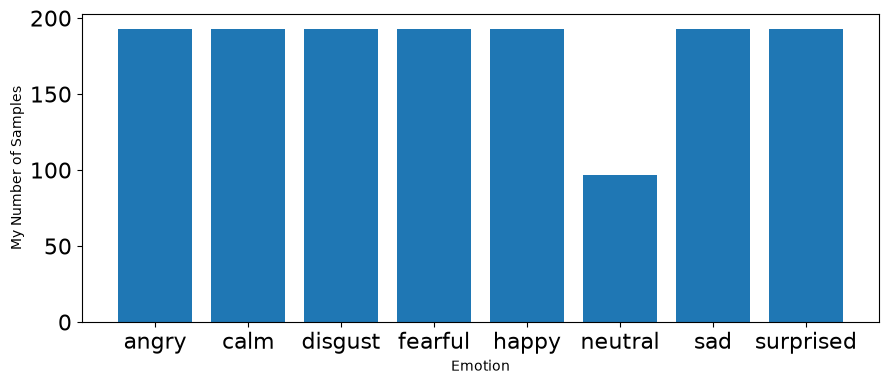

In [370]:
# plot emotions
plt.figure(figsize=(35,4))
plt.subplot(1,3,1)
#np.unique returns ordered list of unique elements and count of each element
emotion_list, count = np.unique(emotions_combined, return_counts=True)
plt.bar(x=range(8), height=count)
plt.xticks(ticks=range(8), labels = [emotion for emotion in emotion_list],fontsize=10)
plt.xlabel('Emotion')
plt.tick_params(labelsize=16)
plt.ylabel('My Number of Samples')
plt.show()

## Emotion + Gender Balance Analysis

In [ ]:
def analyze_gender_by_emotion(file_path):
    male_counts = [0] * 8
    female_counts = [0] * 8

    # Get each directory in the provided file_path
    # Extract emotion code as single digit interger, as well as actor's ID
    # If actor's ID is odd, we know it's a male and increment the value at the index that matches with the value of the emotion inside emotions_dict
    # If actor's ID is even, it's female and we do the same thing

    for file in glob.glob(file_path):
        file_name = os.path.basename(file)
        emotion_code = int(file_name.split("-")[2])
        actor_id = int(file_name.split("-")[6].split(".")[0])
        if actor_id % 2 == 1:
            male_counts[emotion_code - 1] += 1
        else:
            female_counts[emotion_code - 1] += 1

    return male_counts, female_counts

In [372]:
male_counts, female_counts = analyze_gender_by_emotion("./audio/Actor_*/*.wav")

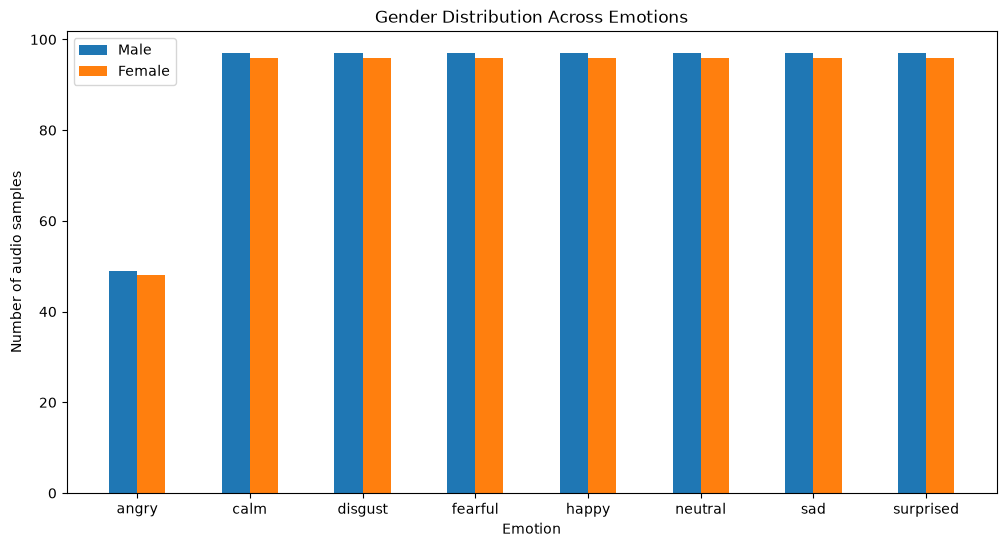

In [373]:
x = np.arange(len(emotion_list))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    male_counts,
    width,
    label="Male"
)

plt.bar(
    x + width / 2,
    female_counts,
    width,
    label="Female"
)

plt.xlabel("Emotion")
plt.ylabel("Number of audio samples")
plt.title("Gender Distribution Across Emotions")

plt.xticks(x, emotion_list)
plt.legend()

plt.show()